In [1]:
import time
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize
import seaborn as sns

plt.rcParams['font.sans-serif']=['SimHei'] #设置默认字体
plt.rcParams['axes.unicode_minus']=False

from lib.envs.gridworld import GridworldEnv

In [2]:
# 定义1个全局变量来记录运算的次数
i_num = 0
convergence_history = []


# 根据传入的四个行为选择值函数最大的索引，返回一个索引数组(行为动作0,1,2 or 3)和一个行为策略
def get_max_index(action_values):
    indexs = []
    policy_arr = np.zeros(len(action_values))
    action_max_value = np.max(action_values)
    for i in range(len(action_values)):
        action_value = action_values[i]
        if action_value == action_max_value:
            indexs.append(i)
            policy_arr[i] = 1
    return indexs, policy_arr


# 将策略中每行可能行为改为元组形式，方便对多个方向的表示
def change_policy(policys):
    action_tuple = []
    for policy in policys:
        indexs, policy_arr = get_max_index(policy)
        action_tuple.append(tuple(indexs))
    return action_tuple

def value_iteration(env, threshold=0.0001, discount_factor=1.0):
    '''
    值迭代算法
        env表示环境
        env.P[s][a](prob,next_state,reward,done)记录状态转移概率，下一个状态，回报，是否结束
        env.nS是环境状态空间
        env.nA是环境动作空间
        discount_factor:折扣因子
        返回：最优策略和最优值函数
        '''
    global i_num
    global convergence_history
    
    def one_step_lookahead(state, V):
        q = np.zeros(env.nA)
        for a in range(env.nA):
            for prob, next_state, reward, done in env.P[state][a]:
                q[a] += prob * (reward +discount_factor * V[next_state])
                # q[a] += reward + discount_factor * prob * V[next_state] 
                # 此表达式不正确，若prob为概率，即给出s,a，产生不同s',prob不为1此时P[state][s]应为形如[[prob1, s_1, reward, done],[prob2, s_2, reward, done]]的数据，此时reward重复计算
        return q
    
    start_time = time.perf_counter()

    # 初始化值函数
    V = np.zeros(env.nS)
    V_current = np.zeros(env.nS)

    delta_history = []
    V_history = []
    
    # 通过迭代，得到最优值函数V*
    while True:
        # 停止条件
        delta = 0
        # 遍历每个状态
        for s in range(env.nS):
            # 计算当前状态的各行为值函数
            q = one_step_lookahead(s, V_current)
            # 找到最大行为值函数
            best_action_value = np.max(q)
            # 值函数更新前后求差
            delta = max(delta, np.abs(best_action_value - V_current[s]))
            # 更新当前状态的值函数，即将最大的行为值函数赋值给当前状态，用以更新当前
            # 状态的值函数
            V[s] = best_action_value
        
        i_num += 1
        V_current = np.copy(V)
        
        # 记录收敛历史
        delta_history.append(delta)
        V_history.append(V_current.copy())
        convergence_history.append(i_num)
        
        # if i_num <= 4:
        print(f"迭代 {i_num}: delta = {delta:.4f}")
        print(f"值函数矩阵:\n{V.reshape(5,5)}\n")
        
        if delta < threshold:
            print(f"收敛于 {i_num} 次迭代, 最终 delta = {delta:.6f}")
            break
    
    policy = np.zeros([env.nS, env.nA])
    for s in range(env.nS):
        # 根据已经计算出的 V, 计算当前状态的各行为值函数
        q = one_step_lookahead(s, V)
        # 求出当前最大行为值函数对应的动作索引
        # 在初始策略中对应的状态上将最大行为值函数方向置1，其余方向保持不变，仍为0
        # 因为np.argmax（action_values）只会选取第一个最大值出现的索引l,
        # 会去掉其他方向的可能性，所以以下方法会输出一个状态下所有的可能性
        best_a_arr, policy_arr = get_max_index(q)
        policy[s] = policy_arr

    stop_time = time.perf_counter()
    print('Duration time is %.3f seconds'%(stop_time - start_time))
    
    return policy, V, delta_history, V_history



In [3]:
env = GridworldEnv()
policy, v, delta_history, V_history = value_iteration(env, discount_factor=1)
update_policy_type = change_policy(policy)

# 将值函数重塑为网格
value_grid = v.reshape(env.shape)
policy_grid = np.reshape(np.argmax(policy, axis=1), env.shape)

迭代 1: delta = 1.0000
值函数矩阵:
[[-1. -1. -1.  0. -1.]
 [-1. -1.  0.  0.  0.]
 [-1. -1. -1.  0. -1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]]

迭代 2: delta = 1.0000
值函数矩阵:
[[-2. -2. -1.  0. -1.]
 [-2. -1.  0.  0.  0.]
 [-2. -2. -1.  0. -1.]
 [-2. -2. -2. -1. -2.]
 [-2. -2. -2. -2. -2.]]

迭代 3: delta = 1.0000
值函数矩阵:
[[-3. -2. -1.  0. -1.]
 [-2. -1.  0.  0.  0.]
 [-3. -2. -1.  0. -1.]
 [-3. -3. -2. -1. -2.]
 [-3. -3. -3. -2. -3.]]

迭代 4: delta = 1.0000
值函数矩阵:
[[-3. -2. -1.  0. -1.]
 [-2. -1.  0.  0.  0.]
 [-3. -2. -1.  0. -1.]
 [-4. -3. -2. -1. -2.]
 [-4. -4. -3. -2. -3.]]

迭代 5: delta = 1.0000
值函数矩阵:
[[-3. -2. -1.  0. -1.]
 [-2. -1.  0.  0.  0.]
 [-3. -2. -1.  0. -1.]
 [-4. -3. -2. -1. -2.]
 [-5. -4. -3. -2. -3.]]

迭代 6: delta = 0.0000
值函数矩阵:
[[-3. -2. -1.  0. -1.]
 [-2. -1.  0.  0.  0.]
 [-3. -2. -1.  0. -1.]
 [-4. -3. -2. -1. -2.]
 [-5. -4. -3. -2. -3.]]

收敛于 6 次迭代, 最终 delta = 0.000000
Duration time is 0.002 seconds


In [4]:
print("update)policy_type:")
print(update_policy_type)
print()

print("Policy Probability Distribution:")
policy = pd.DataFrame(policy,columns=['up','right','down','left'])
print(policy)

update)policy_type:
[(1, 2), (1, 2), (1, 2), (2,), (2, 3), (1,), (1,), (1,), (0, 1, 2, 3), (3,), (0, 1), (0, 1), (0, 1), (0,), (0, 3), (0, 1), (0, 1), (0, 1), (0,), (0, 3), (0, 1), (0, 1), (0, 1), (0,), (0, 3)]

Policy Probability Distribution:
     up  right  down  left
0   0.0    1.0   1.0   0.0
1   0.0    1.0   1.0   0.0
2   0.0    1.0   1.0   0.0
3   0.0    0.0   1.0   0.0
4   0.0    0.0   1.0   1.0
5   0.0    1.0   0.0   0.0
6   0.0    1.0   0.0   0.0
7   0.0    1.0   0.0   0.0
8   1.0    1.0   1.0   1.0
9   0.0    0.0   0.0   1.0
10  1.0    1.0   0.0   0.0
11  1.0    1.0   0.0   0.0
12  1.0    1.0   0.0   0.0
13  1.0    0.0   0.0   0.0
14  1.0    0.0   0.0   1.0
15  1.0    1.0   0.0   0.0
16  1.0    1.0   0.0   0.0
17  1.0    1.0   0.0   0.0
18  1.0    0.0   0.0   0.0
19  1.0    0.0   0.0   1.0
20  1.0    1.0   0.0   0.0
21  1.0    1.0   0.0   0.0
22  1.0    1.0   0.0   0.0
23  1.0    0.0   0.0   0.0
24  1.0    0.0   0.0   1.0


In [5]:
print("Reshaped Grid Policy (0=up, 1=right, 2=down, 3=left):")
print(np.reshape(np.argmax(policy, axis=1), env.shape))
print("")

Reshaped Grid Policy (0=up, 1=right, 2=down, 3=left):
[[1 1 1 2 2]
 [1 1 1 0 3]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]



In [6]:

print("Reshaped Grid Value Function:")
print(v.reshape(env.shape))
print("")

Reshaped Grid Value Function:
[[-3. -2. -1.  0. -1.]
 [-2. -1.  0.  0.  0.]
 [-3. -2. -1.  0. -1.]
 [-4. -3. -2. -1. -2.]
 [-5. -4. -3. -2. -3.]]



# 1. 值函数热力图

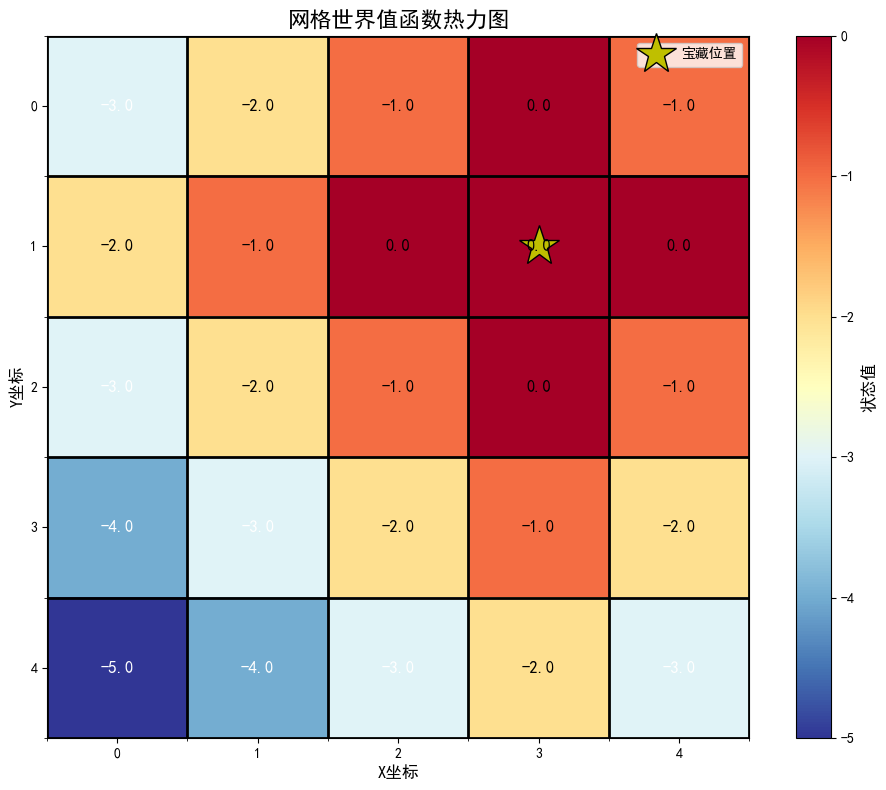

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

# 创建热力图
heatmap = ax.imshow(value_grid, cmap='RdYlBu_r')

# 添加数值标签
for i in range(value_grid.shape[0]):
    for j in range(value_grid.shape[1]):
        value = value_grid[i, j]
        color = 'black' if abs(value) < 2.5 else 'white'
        ax.text(j, i, f'{value:.1f}', 
                ha='center', va='center', 
                color=color, fontsize=12, fontweight='bold')

# 标记宝藏位置（状态8）
treasure_state = 8
treasure_pos = np.unravel_index(treasure_state, env.shape)
ax.plot(treasure_pos[1], treasure_pos[0], 'y*', markersize=30, markeredgecolor='black', label='宝藏位置')

# 设置标题和标签
ax.set_title('网格世界值函数热力图', fontsize=16, fontweight='bold')
ax.set_xlabel('X坐标', fontsize=12)
ax.set_ylabel('Y坐标', fontsize=12)

# 添加网格
ax.set_xticks(np.arange(-0.5, value_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, value_grid.shape[0], 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=2)

# 添加颜色条
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('状态值', fontsize=12)

ax.legend()
plt.tight_layout()
plt.show()

# 2. 策略箭头图

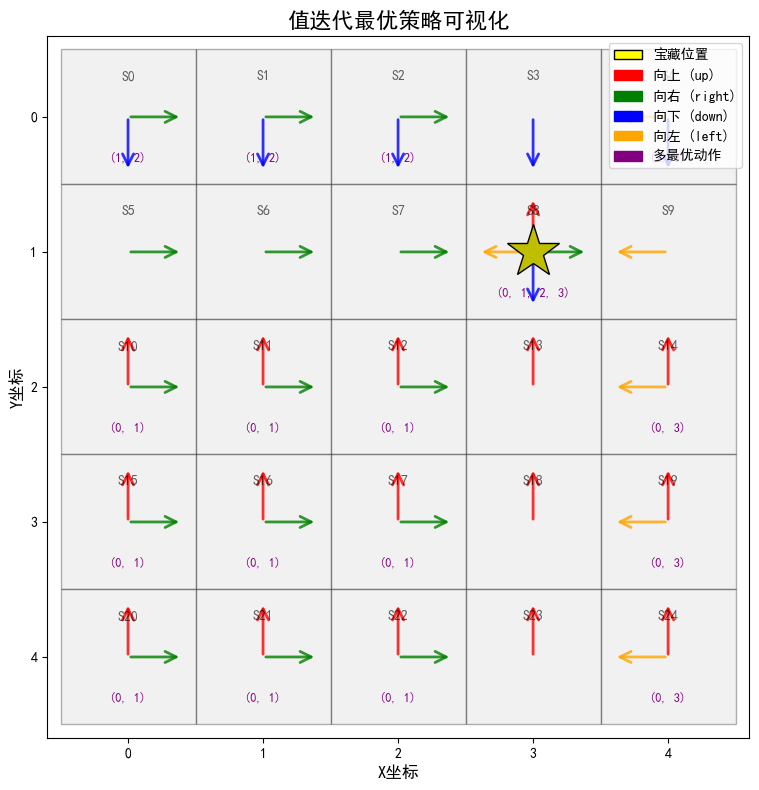

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

# 定义动作到箭头的映射
action_to_direction = {
    0: (0, -0.4),   # up
    1: (0.4, 0),    # right
    2: (0, 0.4),    # down
    3: (-0.4, 0)    # left
}

# 定义动作颜色
action_colors = {
    0: 'red',     # up
    1: 'green',   # right
    2: 'blue',    # down  
    3: 'orange'   # left
}

action_labels = ['up', 'right', 'down', 'left']

# 绘制网格
for i in range(value_grid.shape[0]):
    for j in range(value_grid.shape[1]):
        state = i * value_grid.shape[1] + j
        
        # 绘制单元格
        rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, 
                            fill=True, 
                            edgecolor='black', 
                            facecolor='lightgray', 
                            alpha=0.3)
        ax.add_patch(rect)
        
        # 显示状态编号
        ax.text(j, i-0.3, f'S{state}', 
                ha='center', va='center', 
                fontsize=10, alpha=0.6)
        
        # 如果有多于一个最优动作，绘制所有可能的动作
        if len(update_policy_type[state]) > 1:
            ax.text(j, i+0.3, f'{update_policy_type[state]}', 
                   ha='center', va='center',
                   fontsize=9, color='purple',
                   fontweight='bold')
            
        for action in update_policy_type[state]:
            dx, dy = action_to_direction[action]
            
            # 绘制箭头
            arrow = FancyArrowPatch((j, i), (j+dx, i+dy),
                                   arrowstyle='->',
                                   color=action_colors[action],
                                   mutation_scale=20,
                                   linewidth=2,
                                   alpha=0.8)
            ax.add_patch(arrow)

# 标记宝藏位置
treasure_state = 8
treasure_pos = np.unravel_index(treasure_state, env.shape)
ax.plot(treasure_pos[1], treasure_pos[0], 'y*', 
        markersize=40, markeredgecolor='black', 
        label='宝藏位置', zorder=10)

# 创建图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='yellow', edgecolor='black', label='宝藏位置'),
    Patch(facecolor='red', edgecolor='red', label='向上 (up)'),
    Patch(facecolor='green', edgecolor='green', label='向右 (right)'),
    Patch(facecolor='blue', edgecolor='blue', label='向下 (down)'),
    Patch(facecolor='orange', edgecolor='orange', label='向左 (left)'),
    Patch(facecolor='purple', edgecolor='purple', label='多最优动作')
]

# 设置图形属性
ax.set_xlim(-0.6, value_grid.shape[1]-0.4)
ax.set_ylim(-0.6, value_grid.shape[0]-0.4)
ax.set_aspect('equal')
ax.set_title('值迭代最优策略可视化', fontsize=16, fontweight='bold')
ax.set_xlabel('X坐标', fontsize=12)
ax.set_ylabel('Y坐标', fontsize=12)
ax.invert_yaxis()  # 使y轴向上增加
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

# 3. 值迭代收敛过程

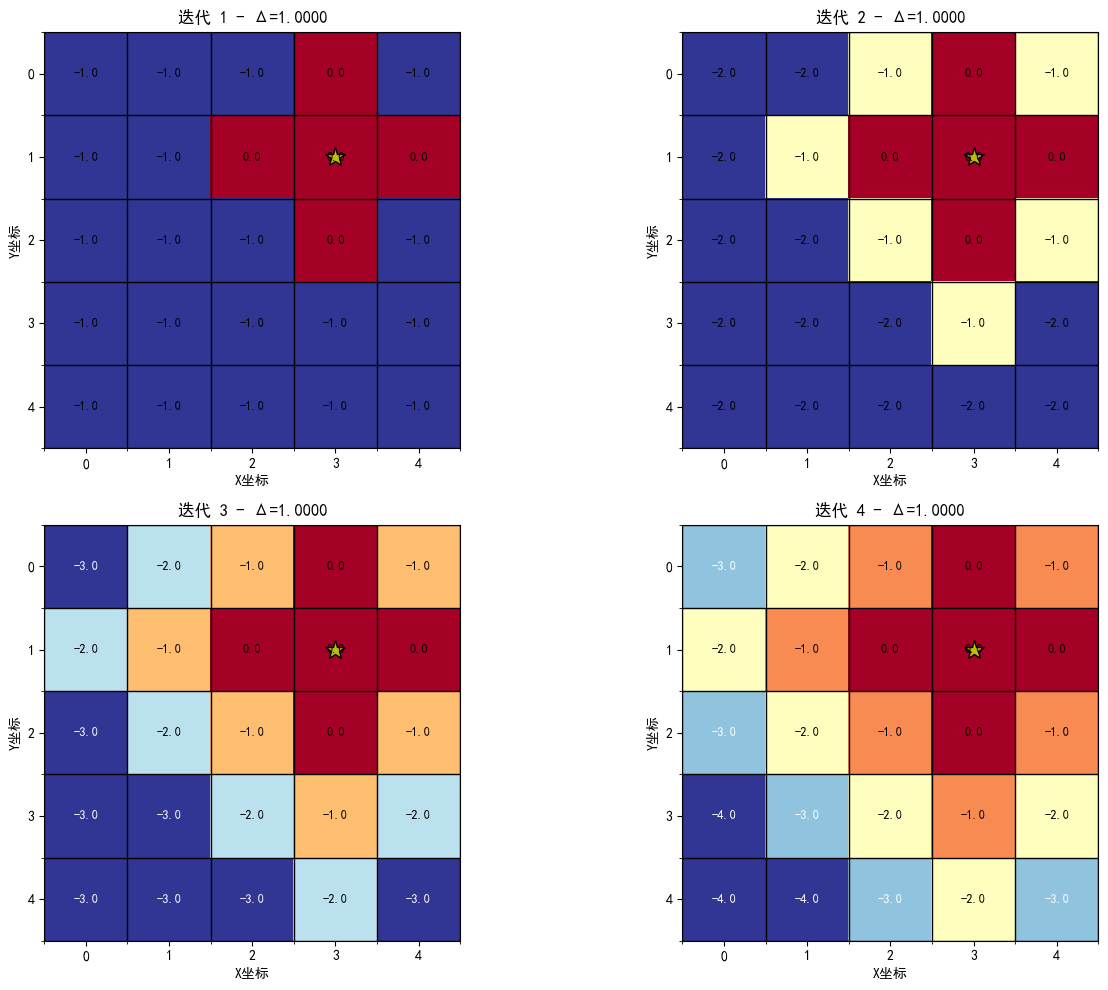

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

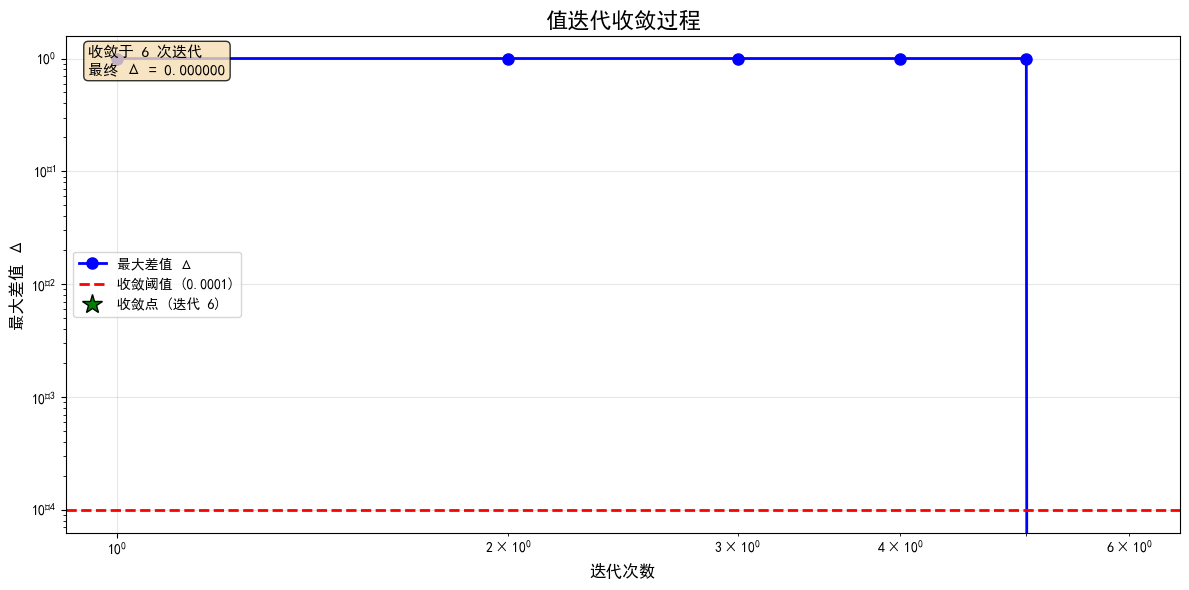

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 显示前4次迭代的值函数矩阵
for i in range(4):
    ax = axes[i]
    if i < len(V_history):
        V_iter = V_history[i].reshape(env.shape)
        
        im = ax.imshow(V_iter, cmap='RdYlBu_r')
        
        # 添加数值标签
        for row in range(V_iter.shape[0]):
            for col in range(V_iter.shape[1]):
                value = V_iter[row, col]
                color = 'black' if abs(value) < 2.5 else 'white'
                ax.text(col, row, f'{value:.1f}', 
                        ha='center', va='center', 
                        color=color, fontsize=9)
        
        ax.set_title(f'迭代 {i+1} - Δ={delta_history[i]:.4f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('X坐标', fontsize=10)
        ax.set_ylabel('Y坐标', fontsize=10)
        
        # 添加网格
        ax.set_xticks(np.arange(-0.5, V_iter.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, V_iter.shape[0], 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
        
        # 标记宝藏位置
        ax.plot(treasure_pos[1], treasure_pos[0], 'y*', 
                markersize=15, markeredgecolor='black')

# 调整布局
plt.tight_layout()
plt.show()

# 收敛曲线
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制delta收敛曲线
iterations = range(1, len(delta_history) + 1)
ax.plot(iterations, delta_history, 'b-o', linewidth=2, markersize=8, label='最大差值 Δ')

# 添加阈值线
ax.axhline(y=0.0001, color='r', linestyle='--', linewidth=2, label='收敛阈值 (0.0001)')

# 标记收敛点
convergence_iter = len(delta_history)
ax.plot(convergence_iter, delta_history[-1], 'g*', markersize=15, 
        label=f'收敛点 (迭代 {convergence_iter})', markeredgecolor='black')

# 设置图形属性
ax.set_xlabel('迭代次数', fontsize=12)
ax.set_ylabel('最大差值 Δ', fontsize=12)
ax.set_title('值迭代收敛过程', fontsize=16, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend()

# 添加收敛信息文本
convergence_text = f"收敛于 {convergence_iter} 次迭代\n最终 Δ = {delta_history[-1]:.6f}"
ax.text(0.02, 0.98, convergence_text,
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=11)

plt.tight_layout()
plt.show()

# 4. 多最优路径可视化

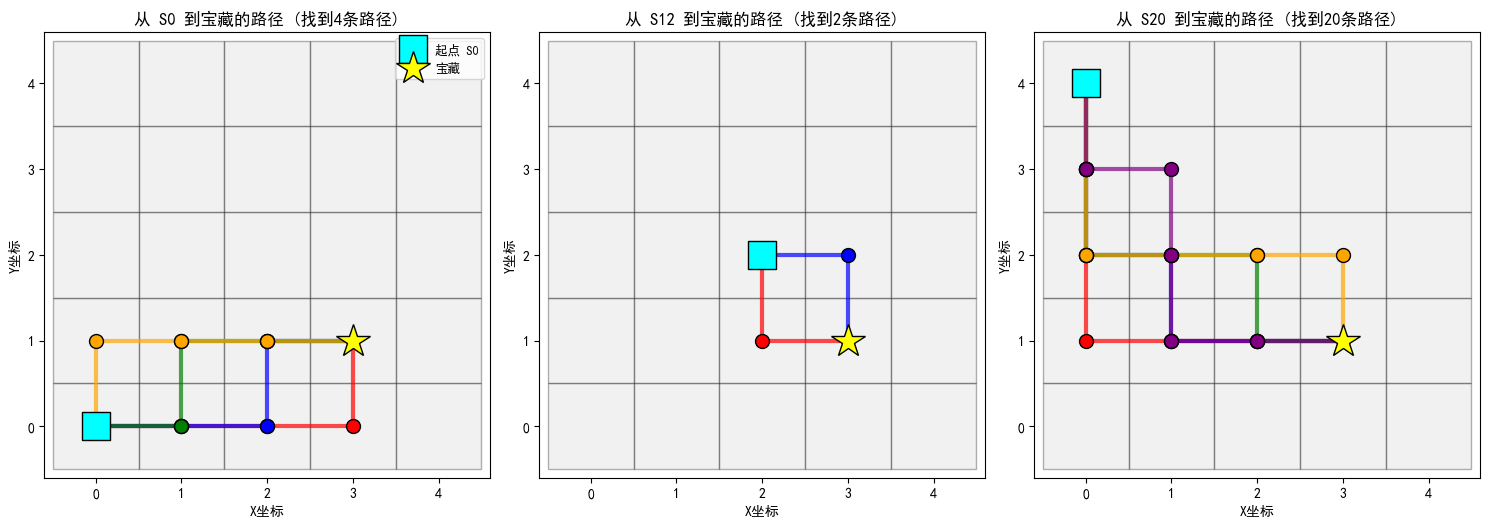


路径分析:

从状态 S0 到宝藏 S8:
  找到 4 条最优路径
  示例路径: S0 → S1 → S2 → S3 → S8
  动作序列: right → right → right → down
  路径长度: 4 步
  还有其他 3 条等效最优路径

从状态 S12 到宝藏 S8:
  找到 2 条最优路径
  示例路径: S12 → S7 → S8
  动作序列: up → right
  路径长度: 2 步
  还有其他 1 条等效最优路径

从状态 S20 到宝藏 S8:
  找到 20 条最优路径
  示例路径: S20 → S15 → S10 → S5 → S6 → S7 → S8
  动作序列: up → up → up → right → right → right
  路径长度: 6 步
  还有其他 19 条等效最优路径


In [6]:
def find_optimal_paths(start_state, treasure_state, policy_tuples):
    """寻找从起点到宝藏的所有最优路径"""
    def dfs(current_state, path, visited):
        if current_state == treasure_state:
            return [path.copy()]
        
        if current_state in visited:
            return []
        
        visited.add(current_state)
        paths = []
        
        # 获取当前状态的所有最优动作
        optimal_actions = policy_tuples[current_state]
        
        for action in optimal_actions:
            # 找到下一个状态
            next_states = []
            for prob, next_state, reward, done in env.P[current_state][action]:
                if prob > 0:  # 有效的转换
                    next_states.append(next_state)
            
            if next_states:
                next_state = next_states[0]  # 取第一个有效状态
                if next_state != current_state:  # 避免原地不动
                    new_path = path + [(current_state, action, next_state)]
                    found_paths = dfs(next_state, new_path, visited.copy())
                    paths.extend(found_paths)
        
        return paths
    
    return dfs(start_state, [], set())

# 从几个不同的起点寻找路径
start_states = [0, 12, 20]
treasure_state = 8

fig, axes = plt.subplots(1, len(start_states), figsize=(15, 5))
if len(start_states) == 1:
    axes = [axes]

path_colors = ['red', 'blue', 'green', 'orange', 'purple']

for idx, start_state in enumerate(start_states):
    ax = axes[idx]
    
    # 寻找路径
    paths = find_optimal_paths(start_state, treasure_state, update_policy_type)
    
    # 绘制网格
    for i in range(value_grid.shape[0]):
        for j in range(value_grid.shape[1]):
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, 
                                fill=True, 
                                edgecolor='black', 
                                facecolor='lightgray', 
                                alpha=0.3)
            ax.add_patch(rect)
    
    # 绘制路径
    for path_idx, path in enumerate(paths[:5]):  # 只显示前5条路径
        color = path_colors[path_idx % len(path_colors)]
        
        # 绘制路径线段
        for src_state, action, dst_state in path:
            src_pos = np.unravel_index(src_state, env.shape)
            dst_pos = np.unravel_index(dst_state, env.shape)
            
            # 绘制线段
            ax.plot([src_pos[1], dst_pos[1]], 
                   [src_pos[0], dst_pos[0]], 
                   color=color, linewidth=3, alpha=0.7, zorder=5)
            
            # 绘制起点
            ax.plot(src_pos[1], src_pos[0], 'o', 
                   color=color, markersize=10, markeredgecolor='black', zorder=6)
    
    # 标记起点和终点
    start_pos = np.unravel_index(start_state, env.shape)
    ax.plot(start_pos[1], start_pos[0], 's', 
           color='black', markersize=20, 
           markeredgecolor='black', markerfacecolor='cyan', 
           label=f'起点 S{start_state}', zorder=7)
    
    ax.plot(treasure_pos[1], treasure_pos[0], '*', 
           color='yellow', markersize=25, 
           markeredgecolor='black', 
           label='宝藏', zorder=7)
    
    ax.set_title(f'从 S{start_state} 到宝藏的路径 (找到{len(paths)}条路径)', fontsize=12, fontweight='bold')
    ax.set_xlabel('X坐标', fontsize=10)
    ax.set_ylabel('Y坐标', fontsize=10)
    ax.invert_yaxis()
    ax.set_xlim(-0.6, value_grid.shape[1]-0.4)
    ax.set_ylim(-0.6, value_grid.shape[0]-0.4)
    ax.set_aspect('equal')
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# 打印路径信息
print("\n路径分析:")
for start_state in start_states:
    paths = find_optimal_paths(start_state, treasure_state, update_policy_type)
    print(f"\n从状态 S{start_state} 到宝藏 S{treasure_state}:")
    print(f"  找到 {len(paths)} 条最优路径")
    
    if paths:
        # 显示第一条路径
        path = paths[0]
        path_states = [start_state]
        path_actions = []
        action_names = ['up', 'right', 'down', 'left']
        
        for src_state, action, dst_state in path:
            path_states.append(dst_state)
            path_actions.append(action_names[action])
        
        print(f"  示例路径: {' → '.join([f'S{s}' for s in path_states])}")
        print(f"  动作序列: {' → '.join(path_actions)}")
        print(f"  路径长度: {len(path)} 步")
        
        if len(paths) > 1:
            print(f"  还有其他 {len(paths)-1} 条等效最优路径")

# 5. 综合仪表板

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

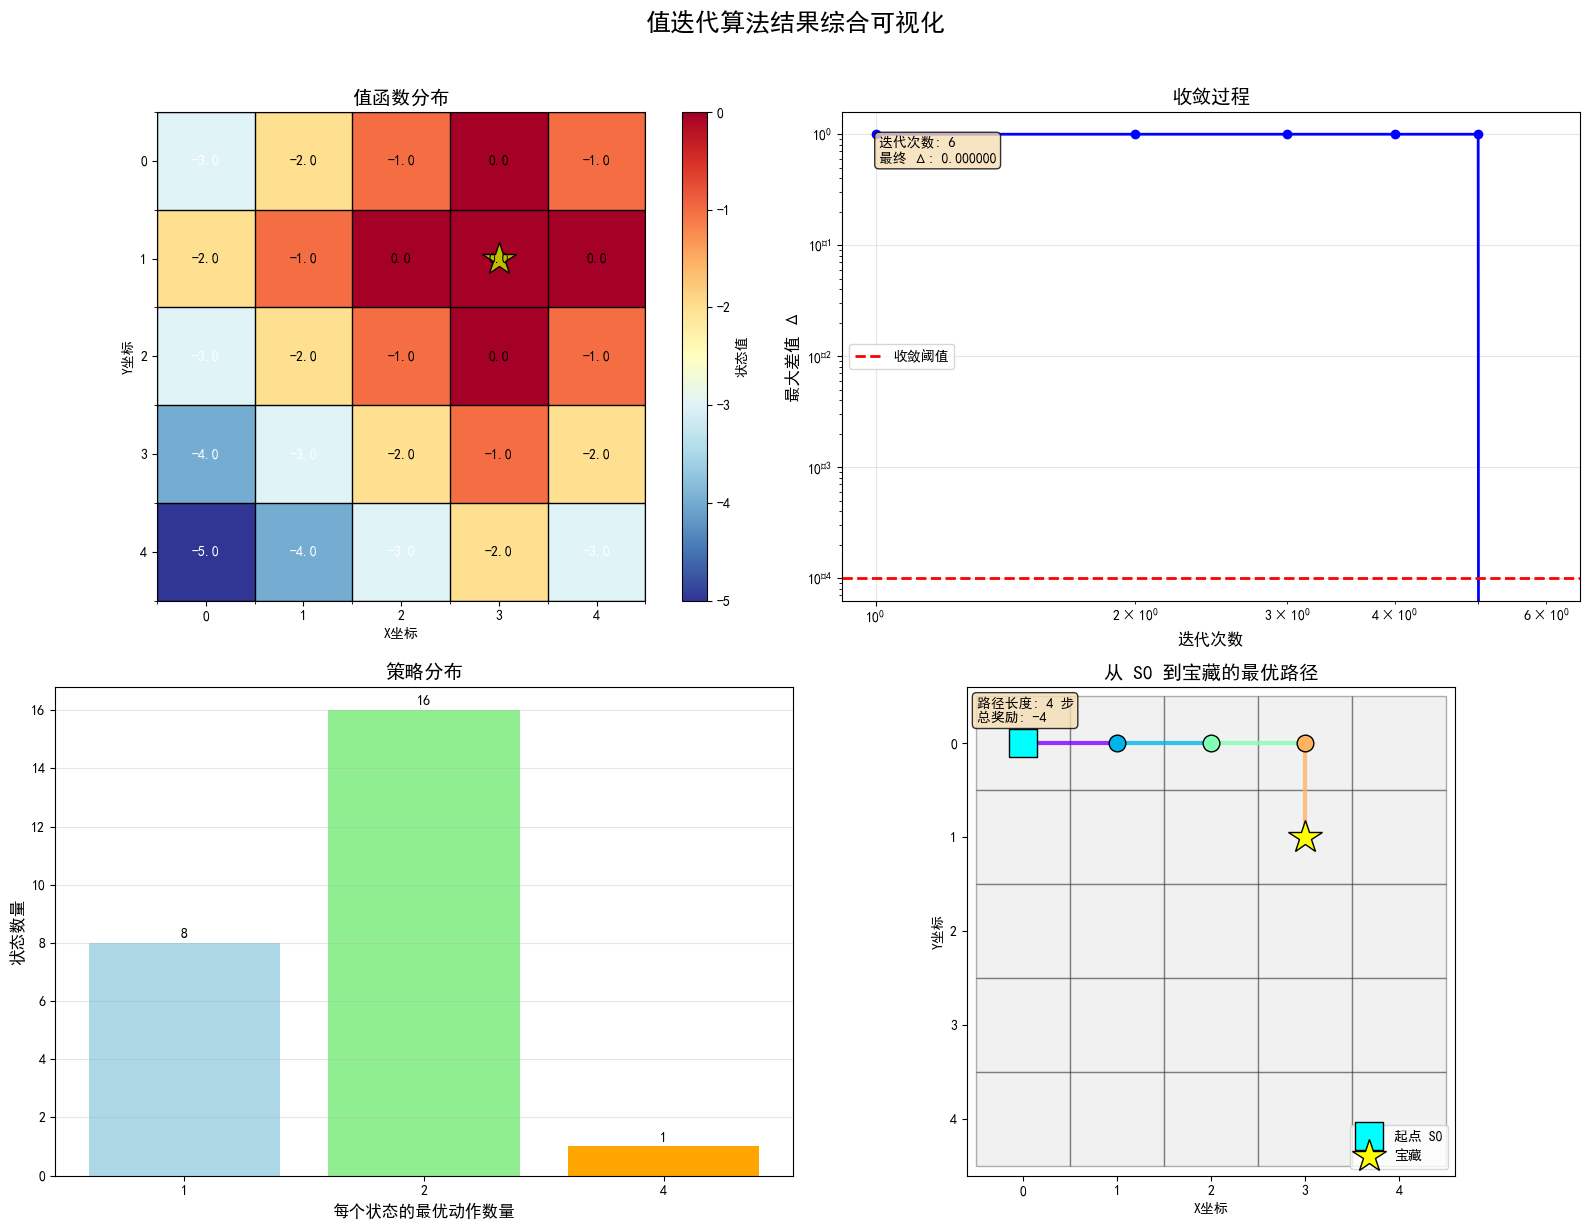


值迭代算法统计信息
网格大小: 5 × 5 (共25个状态)
动作空间: 4个动作 (up, right, down, left)
折扣因子: 1.0
收敛阈值: 0.0001
迭代次数: 6
最终 Δ 值: 0.000000
宝藏位置: 状态 8 (坐标 (np.int64(1), np.int64(3)))
每个状态平均最优动作数: 1.76
有多个最优动作的状态数: 17


In [7]:
# 创建综合仪表板
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. 值函数热力图
im1 = ax1.imshow(value_grid, cmap='RdYlBu_r')
for i in range(value_grid.shape[0]):
    for j in range(value_grid.shape[1]):
        value = value_grid[i, j]
        color = 'black' if abs(value) < 2.5 else 'white'
        ax1.text(j, i, f'{value:.1f}', 
                ha='center', va='center', 
                color=color, fontsize=10, fontweight='bold')
ax1.plot(treasure_pos[1], treasure_pos[0], 'y*', markersize=25, markeredgecolor='black')
ax1.set_xticks(np.arange(-0.5, value_grid.shape[1], 1), minor=True)
ax1.set_yticks(np.arange(-0.5, value_grid.shape[0], 1), minor=True)
ax1.grid(which='minor', color='black', linestyle='-', linewidth=1)
ax1.set_title('值函数分布', fontsize=14, fontweight='bold')
ax1.set_xlabel('X坐标')
ax1.set_ylabel('Y坐标')
plt.colorbar(im1, ax=ax1, label='状态值')

# 2. 收敛曲线
ax2.plot(range(1, len(delta_history)+1), delta_history, 'b-o', linewidth=2, markersize=6)
ax2.axhline(y=0.0001, color='r', linestyle='--', linewidth=2, label='收敛阈值')
ax2.plot(len(delta_history), delta_history[-1], 'g*', markersize=15, markeredgecolor='black')
ax2.set_xlabel('迭代次数', fontsize=12)
ax2.set_ylabel('最大差值 Δ', fontsize=12)
ax2.set_title('收敛过程', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend()
convergence_info = f"迭代次数: {len(delta_history)}\n最终 Δ: {delta_history[-1]:.6f}"
ax2.text(0.05, 0.95, convergence_info,
        transform=ax2.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=10)

# 3. 策略分布条形图
policy_counts = pd.Series([len(p) for p in update_policy_type]).value_counts().sort_index()
bars = ax3.bar(policy_counts.index.astype(str), policy_counts.values, 
              color=['lightblue', 'lightgreen', 'orange', 'pink'])
ax3.set_xlabel('每个状态的最优动作数量', fontsize=12)
ax3.set_ylabel('状态数量', fontsize=12)
ax3.set_title('策略分布', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

# 4. 起点到终点路径示例
start_state = 0
paths = find_optimal_paths(start_state, treasure_state, update_policy_type)
if paths:
    path = paths[0]
    # 绘制网格
    for i in range(value_grid.shape[0]):
        for j in range(value_grid.shape[1]):
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, 
                                fill=True, 
                                edgecolor='black', 
                                facecolor='lightgray', 
                                alpha=0.3)
            ax4.add_patch(rect)
    
    # 绘制路径
    colors = plt.cm.rainbow(np.linspace(0, 1, len(path)+1))
    
    path_states = [start_state]
    for idx, (src_state, action, dst_state) in enumerate(path):
        src_pos = np.unravel_index(src_state, env.shape)
        dst_pos = np.unravel_index(dst_state, env.shape)
        
        ax4.plot([src_pos[1], dst_pos[1]], 
                [src_pos[0], dst_pos[0]], 
                color=colors[idx], linewidth=3, alpha=0.8, zorder=5)
        
        ax4.plot(src_pos[1], src_pos[0], 'o', 
                color=colors[idx], markersize=12, 
                markeredgecolor='black', zorder=6)
        
        path_states.append(dst_state)
    
    # 标记起点和终点
    start_pos = np.unravel_index(start_state, env.shape)
    ax4.plot(start_pos[1], start_pos[0], 's', 
            color='black', markersize=20, 
            markeredgecolor='black', markerfacecolor='cyan', 
            label=f'起点 S{start_state}', zorder=7)
    
    ax4.plot(treasure_pos[1], treasure_pos[0], '*', 
            color='yellow', markersize=25, 
            markeredgecolor='black', label='宝藏', zorder=7)
    
    ax4.set_xlim(-0.6, value_grid.shape[1]-0.4)
    ax4.set_ylim(-0.6, value_grid.shape[0]-0.4)
    ax4.invert_yaxis()
    ax4.set_aspect('equal')
    
    path_info = f"路径长度: {len(path)} 步\n"
    path_info += f"总奖励: {len(path) * -1}"
    ax4.text(0.02, 0.98, path_info,
            transform=ax4.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=10)
    
    ax4.legend(loc='lower right')

ax4.set_title(f'从 S{start_state} 到宝藏的最优路径', fontsize=14, fontweight='bold')
ax4.set_xlabel('X坐标')
ax4.set_ylabel('Y坐标')

plt.suptitle('值迭代算法结果综合可视化', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 打印算法统计信息
print("\n" + "="*60)
print("值迭代算法统计信息")
print("="*60)
print(f"网格大小: {env.shape[0]} × {env.shape[1]} (共{env.nS}个状态)")
print(f"动作空间: {env.nA}个动作 (up, right, down, left)")
print(f"折扣因子: {1.0}")
print(f"收敛阈值: {0.0001}")
print(f"迭代次数: {len(delta_history)}")
print(f"最终 Δ 值: {delta_history[-1]:.6f}")
print(f"宝藏位置: 状态 {treasure_state} (坐标 {treasure_pos})")
print(f"每个状态平均最优动作数: {np.mean([len(p) for p in update_policy_type]):.2f}")
print(f"有多个最优动作的状态数: {sum(1 for p in update_policy_type if len(p) > 1)}")
print("="*60)